<a href="https://colab.research.google.com/github/richards07-afk/LINEAR-MODELS/blob/main/LinearModels_FA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA DIMENSIONS
Number of observations: 142
Number of variables: 6

VARIABLE TYPES
country           object
year               int64
pop              float64
continent         object
lifeExp          float64
gdpPercap        float64
log_gdpPercap    float64
dtype: object

MISSING VALUES
country          0
year             0
pop              0
continent        0
lifeExp          0
gdpPercap        0
log_gdpPercap    0
dtype: int64

NUMERICAL SUMMARY: lifeExp
{'mean': np.float64(67.00742253521126), 'sd': 12.07302050222512, 'min': 39.613, 'q1': np.float64(57.16025), 'median': 71.93549999999999, 'q3': np.float64(76.41325), 'max': 82.603, 'iqr': np.float64(19.253000000000007), 'skewness': np.float64(-0.6887770648577503)}

NUMERICAL SUMMARY: gdpPercap
{'mean': np.float64(11680.071819878167), 'sd': 12859.937337422318, 'min': 277.5518587, 'q1': np.float64(1624.84224775), 'median': 6124.3711084999995, 'q3': np.float64(18008.835639999998), 'max': 49357.19017, 'iqr': np.float64(16383.993392249997

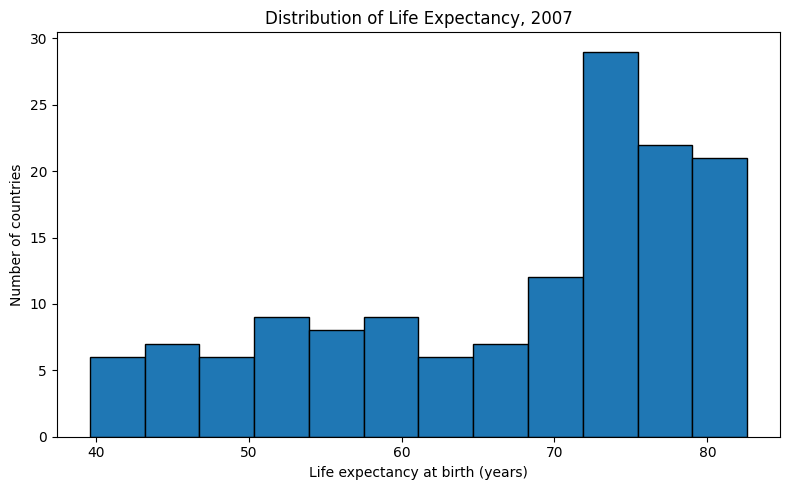

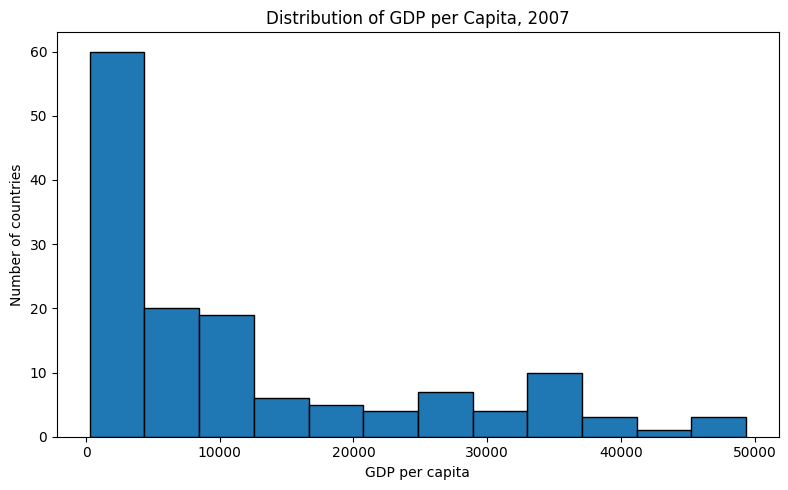

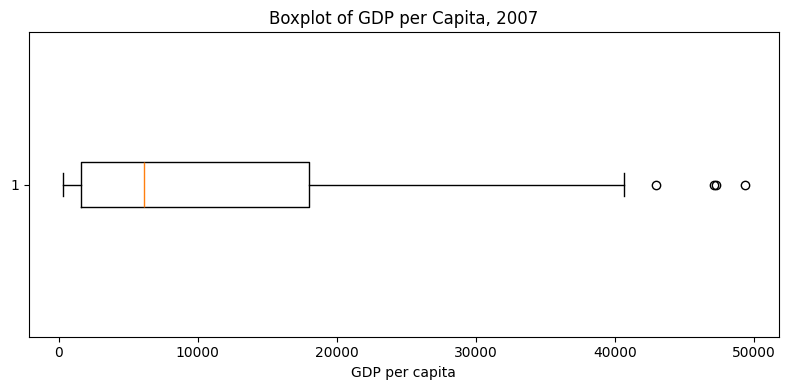


GDP PER CAPITA OUTLIERS
Lower fence: -22951.147840624995
Upper fence: 42584.82572837499
            country    gdpPercap
1619  United States  42951.65309
1367      Singapore  47143.17964
863          Kuwait  47306.98978
1151         Norway  49357.19017


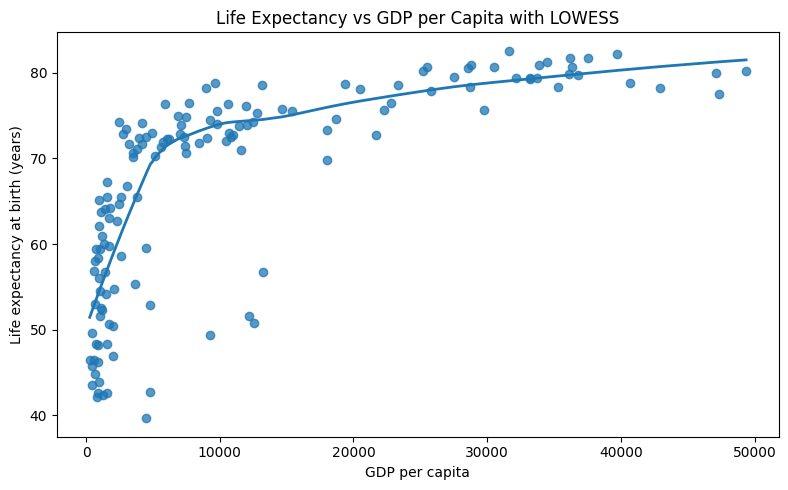


Original-scale correlation: 0.6786623986777586


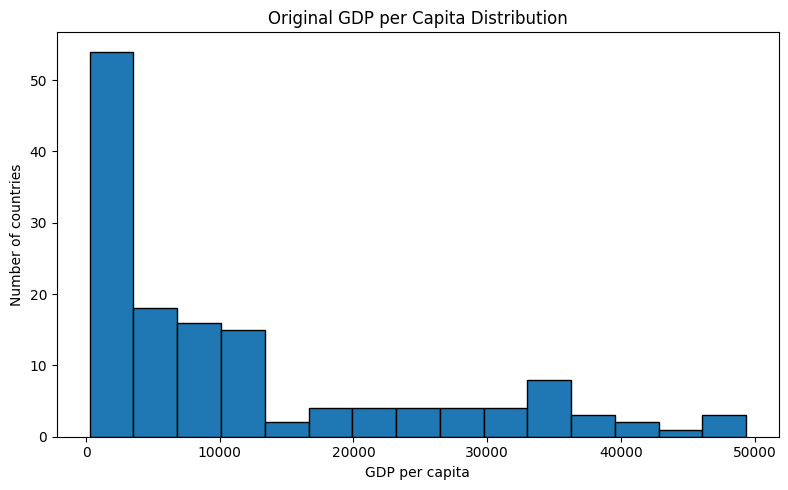

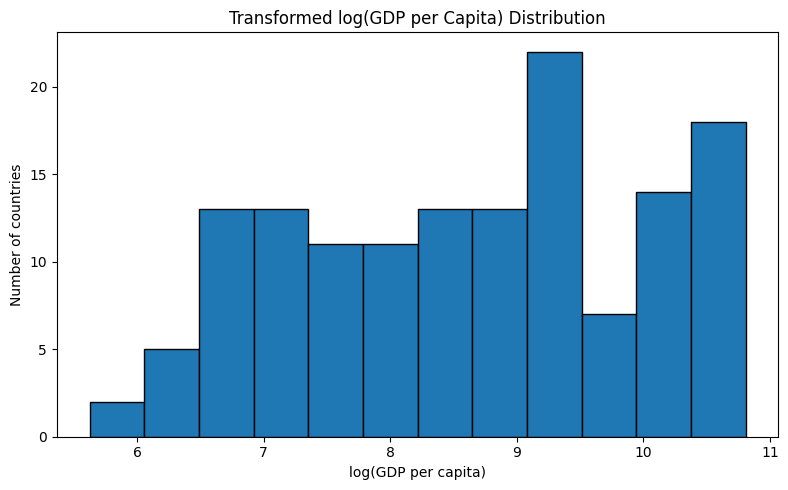

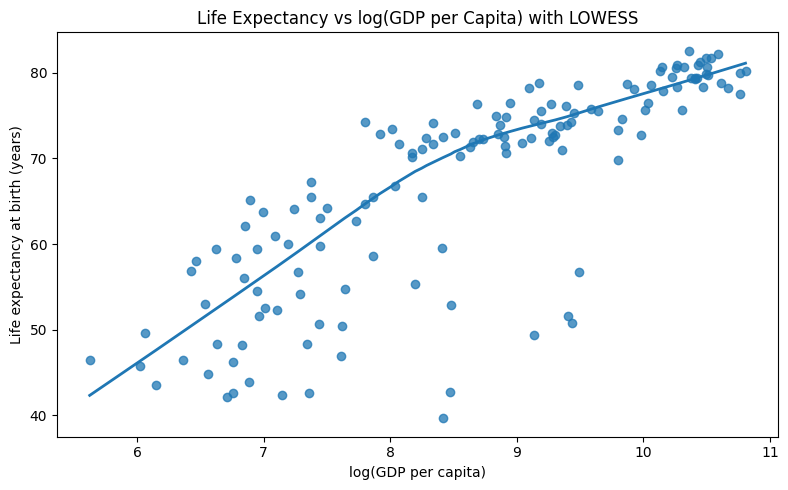


TRANSFORMATION COMPARISON
Original GDP skewness: 1.2241976779635677
Log GDP skewness: -0.15405242608017
Original GDP symmetry ratio: 2.6412686526293436
Log GDP symmetry ratio: 0.8128239637065203

MODEL 1 SUMMARY
                            OLS Regression Results                            
Dep. Variable:                lifeExp   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     119.5
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           1.69e-20
Time:                        13:40:59   Log-Likelihood:                -510.88
No. Observations:                 142   AIC:                             1026.
Df Residuals:                     140   BIC:                             1032.
Df Model:                           1                                         
Covariance Type:            nonrobust                                       

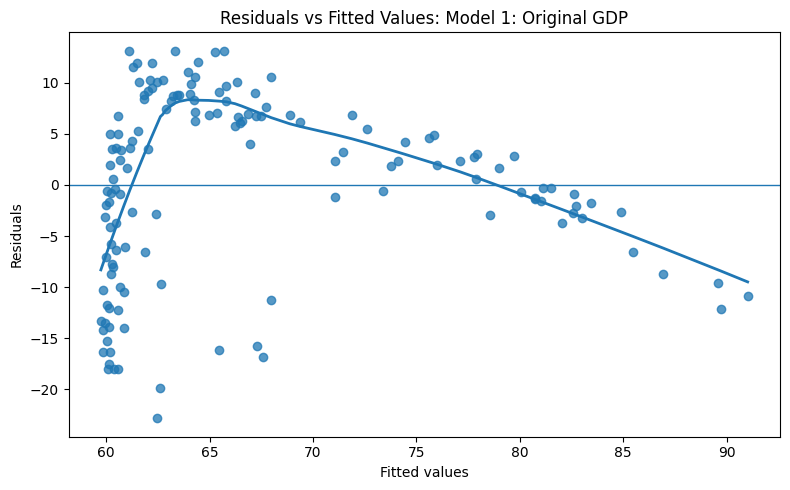

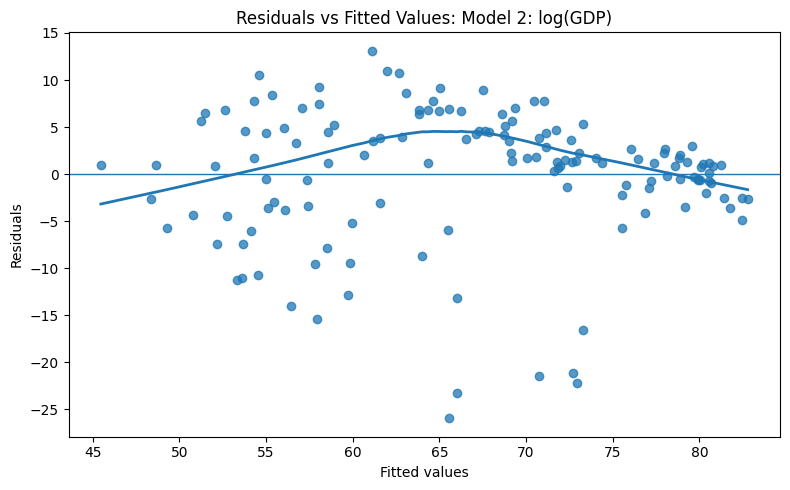

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import skew

url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
gapminder = pd.read_csv(url)

df = gapminder[gapminder["year"] == 2007].copy()

df["log_gdpPercap"] = np.log(df["gdpPercap"])

print("DATA DIMENSIONS")
print("Number of observations:", len(df))
print("Number of variables:", df.shape[1] - 1)
print("\nVARIABLE TYPES")
print(df.dtypes)
print("\nMISSING VALUES")
print(df.isna().sum())

def numerical_summary(series):
    return {
        "mean": series.mean(),
        "sd": series.std(ddof=1),
        "min": series.min(),
        "q1": series.quantile(0.25),
        "median": series.median(),
        "q3": series.quantile(0.75),
        "max": series.max(),
        "iqr": series.quantile(0.75) - series.quantile(0.25),
        "skewness": skew(series, bias=False)
    }

for variable in ["lifeExp", "gdpPercap"]:
    print(f"\nNUMERICAL SUMMARY: {variable}")
    print(numerical_summary(df[variable]))

for variable, xlabel, title in [
    ("lifeExp", "Life expectancy at birth (years)", "Distribution of Life Expectancy, 2007"),
    ("gdpPercap", "GDP per capita", "Distribution of GDP per Capita, 2007")
]:
    plt.figure(figsize=(8,5))
    plt.hist(df[variable], bins=12, edgecolor="black")
    plt.xlabel(xlabel)
    plt.ylabel("Number of countries")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8,4))
plt.boxplot(df["gdpPercap"], vert=False)
plt.xlabel("GDP per capita")
plt.title("Boxplot of GDP per Capita, 2007")
plt.tight_layout()
plt.show()

def iqr_outliers(data, variable):
    q1, q3 = data[variable].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[variable] < lower) | (data[variable] > upper)]
    return lower, upper, outliers[["country", variable]].sort_values(variable)

lower, upper, outliers = iqr_outliers(df, "gdpPercap")
print("\nGDP PER CAPITA OUTLIERS")
print("Lower fence:", lower)
print("Upper fence:", upper)
print(outliers)

plt.figure(figsize=(8,5))
plt.scatter(df["gdpPercap"], df["lifeExp"], alpha=0.75)
smooth = lowess(df["lifeExp"], df["gdpPercap"], frac=0.6, return_sorted=True)
plt.plot(smooth[:,0], smooth[:,1], linewidth=2)
plt.xlabel("GDP per capita")
plt.ylabel("Life expectancy at birth (years)")
plt.title("Life Expectancy vs GDP per Capita with LOWESS")
plt.tight_layout()
plt.show()

print("\nOriginal-scale correlation:", df["lifeExp"].corr(df["gdpPercap"]))

plt.figure(figsize=(8,5))
plt.hist(df["gdpPercap"], bins=15, edgecolor="black")
plt.xlabel("GDP per capita")
plt.ylabel("Number of countries")
plt.title("Original GDP per Capita Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["log_gdpPercap"], bins=12, edgecolor="black")
plt.xlabel("log(GDP per capita)")
plt.ylabel("Number of countries")
plt.title("Transformed log(GDP per Capita) Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["log_gdpPercap"], df["lifeExp"], alpha=0.75)
smooth = lowess(df["lifeExp"], df["log_gdpPercap"], frac=0.6, return_sorted=True)
plt.plot(smooth[:,0], smooth[:,1], linewidth=2)
plt.xlabel("log(GDP per capita)")
plt.ylabel("Life expectancy at birth (years)")
plt.title("Life Expectancy vs log(GDP per Capita) with LOWESS")
plt.tight_layout()
plt.show()

def symmetry_ratio(series):
    q1, median, q3 = series.quantile([0.25, 0.50, 0.75])
    return (q3 - median) / (median - q1)

print("\nTRANSFORMATION COMPARISON")
print("Original GDP skewness:", skew(df["gdpPercap"], bias=False))
print("Log GDP skewness:", skew(df["log_gdpPercap"], bias=False))
print("Original GDP symmetry ratio:", symmetry_ratio(df["gdpPercap"]))
print("Log GDP symmetry ratio:", symmetry_ratio(df["log_gdpPercap"]))

X1 = sm.add_constant(df["gdpPercap"])
model1 = sm.OLS(df["lifeExp"], X1).fit()

X2 = sm.add_constant(df["log_gdpPercap"])
model2 = sm.OLS(df["lifeExp"], X2).fit()

print("\nMODEL 1 SUMMARY")
print(model1.summary())
print("\nMODEL 2 SUMMARY")
print(model2.summary())

for name, model in [("Model 1", model1), ("Model 2", model2)]:
    rse = np.sqrt(model.ssr / model.df_resid)
    print(f"\n{name}")
    print("R-squared:", model.rsquared)
    print("Adjusted R-squared:", model.rsquared_adj)
    print("Residual standard error:", rse)

for name, model in [("Model 1: Original GDP", model1),
                    ("Model 2: log(GDP)", model2)]:
    plt.figure(figsize=(8,5))
    plt.scatter(model.fittedvalues, model.resid, alpha=0.75)
    plt.axhline(0, linewidth=1)
    smooth = lowess(model.resid, model.fittedvalues, frac=0.6, return_sorted=True)
    plt.plot(smooth[:,0], smooth[:,1], linewidth=2)
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Fitted Values: {name}")
    plt.tight_layout()
    plt.show()
